# 06 — Compare taxonomy training methods

**Scope:**
- **SimCLR pretrain** (`02`): contrastive loss only (`outputs/ssl_simclr/train_history.csv`). Not comparable to supervised CE.
- **Taxonomy:** SSL finetune `03`, few-shot `04`, FedAvg `05`. Compare `val_metrics_last.json` / `history.csv` where present.

Re-run `02`–`05` as needed so `history.csv` / `train_history.csv` exist.


In [1]:
from pathlib import Path
import json
import os
import re
import sys
import tempfile
import time
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path('..').resolve()
sys.path.insert(0, str((ROOT / 'src').resolve()))

from fish_ai.compress.pipeline import load_taxonomy_checkpoint_auto, load_taxonomy_for_inference

OUT = (ROOT / 'outputs').resolve()


def load_json(path: Path):
    if not path.is_file():
        return None
    return json.loads(path.read_text(encoding='utf-8'))


def load_csv(path: Path):
    if not path.is_file():
        return None
    return pd.read_csv(path)


plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['figure.dpi'] = 110

print('outputs:', OUT)


outputs: D:\Fish Codes\outputs


## 1. SimCLR pretraining (`02`)

`outputs/ssl_simclr/train_history.csv` — NT-Xent. Taxonomy quality comes from notebook `03` val metrics.


In [2]:
ssl_pre = load_csv(OUT / 'ssl_simclr' / 'train_history.csv')
if ssl_pre is None or ssl_pre.empty:
    print('No SimCLR train_history.csv. Run notebook 02.')
else:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(ssl_pre['epoch'], ssl_pre['loss_nt_xent'], marker='o', color='purple')
    ax.set_xlabel('epoch')
    ax.set_ylabel('NT-Xent (train)')
    ax.set_title('SimCLR pretrain - contrastive loss')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


No SimCLR train_history.csv. Run notebook 02.


## 2. Taxonomy — final validation metrics

Loads `val_metrics_last.json` from `taxonomy_ssl`, `federated_fedavg` (if present).


                   family_acc_top1  family_acc_top5  family_f1_macro  family_f1_weighted  genus_acc_top1  genus_acc_top5  genus_f1_macro  genus_f1_weighted  species_acc_top1  species_acc_top5  species_f1_macro  species_f1_weighted
method                                                                                                                                                                                                                                
SSL finetune (03)         0.762894         0.933859         0.672198            0.761876        0.717526        0.898281        0.650429           0.716986          0.981375          0.995702          0.400847             0.977296
FedAvg (05)               0.745941         0.932665         0.597699            0.740285        0.707259        0.888252        0.538309           0.695929          0.972063          0.989016          0.104415             0.964150


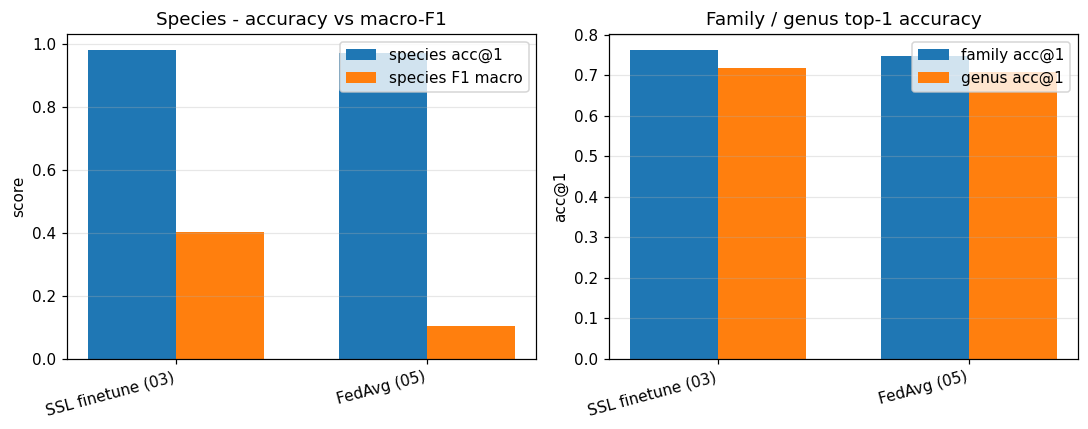

In [3]:
TAX_RUNS = [
    ('SSL finetune (03)', OUT / 'taxonomy_ssl' / 'val_metrics_last.json'),
    ('FedAvg (05)', OUT / 'federated_fedavg' / 'val_metrics_last.json'),
]

rows = []
for name, p in TAX_RUNS:
    m = load_json(p)
    if m is None:
        continue
    row = {'method': name}
    for lvl in ['family', 'genus', 'species']:
        if lvl not in m:
            continue
        for k, v in m[lvl].items():
            row[f'{lvl}_{k}'] = v
    rows.append(row)

metrics_df = pd.DataFrame(rows)
if metrics_df.empty:
    print('No taxonomy val_metrics_last.json found. Run notebooks 03 / 05.')
else:
    metrics_df = metrics_df.set_index('method')
    print(metrics_df.to_string())
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    methods = metrics_df.index.tolist()
    x = np.arange(len(methods))
    w = 0.35
    if 'species_acc_top1' in metrics_df.columns:
        axes[0].bar(x - w / 2, metrics_df['species_acc_top1'], w, label='species acc@1')
    if 'species_f1_macro' in metrics_df.columns:
        axes[0].bar(x + w / 2, metrics_df['species_f1_macro'], w, label='species F1 macro')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(methods, rotation=15, ha='right')
    axes[0].set_ylabel('score')
    axes[0].set_title('Species - accuracy vs macro-F1')
    axes[0].legend()
    axes[0].grid(True, axis='y', alpha=0.3)

    if 'genus_acc_top1' in metrics_df.columns and 'family_acc_top1' in metrics_df.columns:
        axes[1].bar(x - w / 2, metrics_df['family_acc_top1'], w, label='family acc@1')
        axes[1].bar(x + w / 2, metrics_df['genus_acc_top1'], w, label='genus acc@1')
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(methods, rotation=15, ha='right')
        axes[1].set_ylabel('acc@1')
        axes[1].set_title('Family / genus top-1 accuracy')
        axes[1].legend()
        axes[1].grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


## 3. ENDG511-style: train vs validation (taxonomy)

**Accuracy** and **loss** (train vs val): per **epoch** for SSL finetune; per **round** for FedAvg. Re-run `03` / `05` after `taxonomy_train` updates so `history.csv` includes `train_species_acc_top1`, `val_loss_total`, etc.


In [4]:
hist_ssl = load_csv(OUT / 'taxonomy_ssl' / 'history.csv')


def _plot_tv_acc_loss(hist, title_prefix, xcol='epoch'):
    need = {'train_species_acc_top1', 'val_species_acc_top1', 'loss_total', 'val_loss_total'}
    if hist is None or hist.empty or not need.issubset(set(hist.columns)):
        print(f'Skip {title_prefix}: need columns {need} in history (re-train 03).')
        return
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    ax = axes[0]
    ax.plot(hist[xcol], hist['train_species_acc_top1'], marker='o', label='train')
    ax.plot(hist[xcol], hist['val_species_acc_top1'], marker='o', label='val')
    ax.set_xlabel(xcol)
    ax.set_ylabel('species acc@1')
    ax.set_title(f'{title_prefix} - accuracy')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax = axes[1]
    ax.plot(hist[xcol], hist['loss_total'], marker='o', label='train')
    ax.plot(hist[xcol], hist['val_loss_total'], marker='o', label='val')
    ax.set_xlabel(xcol)
    ax.set_ylabel('loss (mean CE sum / sample on val)')
    ax.set_title(f'{title_prefix} - loss')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


_plot_tv_acc_loss(hist_ssl, 'SSL finetune (03)')

hist_fed = load_csv(OUT / 'federated_fedavg' / 'history.csv')
if hist_fed is None or hist_fed.empty:
    print('No FedAvg history')
else:
    need = {'train_species_acc_top1_weighted_mean', 'val_species_acc_top1', 'train_loss_total_weighted_mean', 'val_loss_total'}
    if not need.issubset(set(hist_fed.columns)):
        print('FedAvg: need train/val acc+loss columns (re-run 05).')
    else:
        fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
        ax = axes[0]
        ax.plot(hist_fed['round'], hist_fed['train_species_acc_top1_weighted_mean'], marker='o', label='train (weighted)')
        ax.plot(hist_fed['round'], hist_fed['val_species_acc_top1'], marker='o', label='val')
        ax.set_xlabel('round')
        ax.set_ylabel('species acc@1')
        ax.set_title('FedAvg (05) - accuracy')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        ax = axes[1]
        ax.plot(hist_fed['round'], hist_fed['train_loss_total_weighted_mean'], marker='o', label='train (weighted)')
        ax.plot(hist_fed['round'], hist_fed['val_loss_total'], marker='o', label='val')
        ax.set_xlabel('round')
        ax.set_ylabel('loss')
        ax.set_title('FedAvg (05) - loss')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


Skip SSL finetune (03): need columns {'train_species_acc_top1', 'val_species_acc_top1', 'loss_total', 'val_loss_total'} in history (re-train 03).
FedAvg: need train/val acc+loss columns (re-run 05).


## 4. Taxonomy — training loss

SSL finetune `03`: `loss_*` per **epoch**. FedAvg `05`: sample-weighted mean train loss per **round** (`train_loss_*_weighted_mean`).


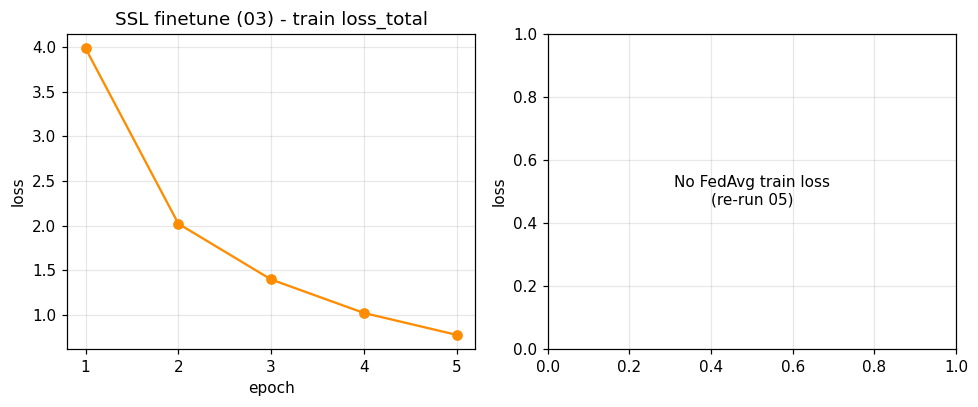

In [5]:
hist_ssl = load_csv(OUT / 'taxonomy_ssl' / 'history.csv')
hist_fed = load_csv(OUT / 'federated_fedavg' / 'history.csv')

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))

if hist_ssl is not None and not hist_ssl.empty and 'loss_total' in hist_ssl.columns:
    axes[0].plot(hist_ssl['epoch'], hist_ssl['loss_total'], marker='o', color='darkorange')
    axes[0].set_title('SSL finetune (03) - train loss_total')
    axes[0].set_xlabel('epoch')
else:
    axes[0].text(0.5, 0.5, 'No SSL finetune history', ha='center', va='center', transform=axes[0].transAxes)

if hist_fed is not None and not hist_fed.empty and 'train_loss_total_weighted_mean' in hist_fed.columns:
    axes[1].plot(hist_fed['round'], hist_fed['train_loss_total_weighted_mean'], marker='o', color='teal')
    axes[1].set_title('FedAvg (05) - weighted mean train loss')
    axes[1].set_xlabel('round')
else:
    axes[1].text(0.5, 0.5, 'No FedAvg train loss\n(re-run 05)', ha='center', va='center', transform=axes[1].transAxes)

for ax in axes:
    ax.set_ylabel('loss')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. FedAvg — validation vs round

Uses `federated_fedavg/history.csv` (`val_*` columns).


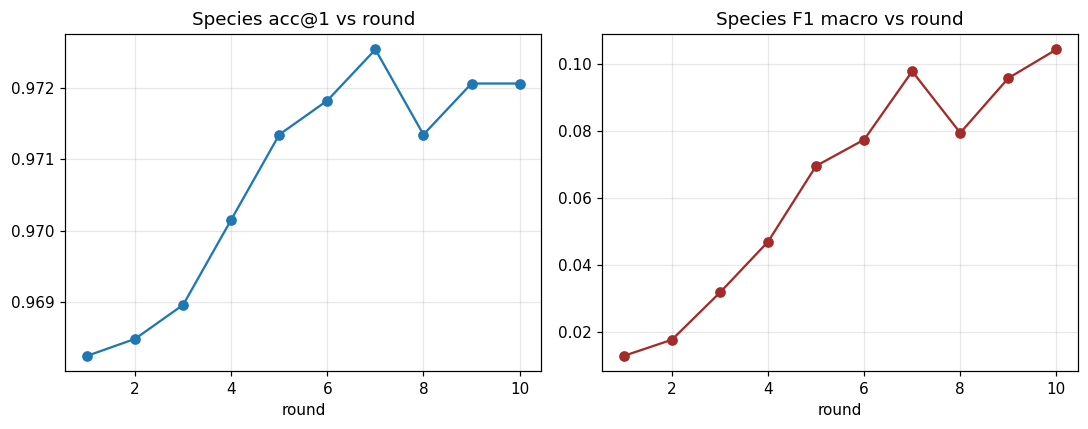

In [6]:
hist_fed = load_csv(OUT / 'federated_fedavg' / 'history.csv')
if hist_fed is None or hist_fed.empty:
    print('No federated history.csv')
else:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    if 'val_species_acc_top1' in hist_fed.columns:
        axes[0].plot(hist_fed['round'], hist_fed['val_species_acc_top1'], marker='o')
        axes[0].set_title('Species acc@1 vs round')
        axes[0].set_xlabel('round')
        axes[0].grid(True, alpha=0.3)
    if 'val_species_f1_macro' in hist_fed.columns:
        axes[1].plot(hist_fed['round'], hist_fed['val_species_f1_macro'], marker='o', color='brown')
        axes[1].set_title('Species F1 macro vs round')
        axes[1].set_xlabel('round')
        axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 6. Few-shot (`04`)

`fewshot_taxonomy/summary.csv` and per-run `k*_seed*/history.csv`.


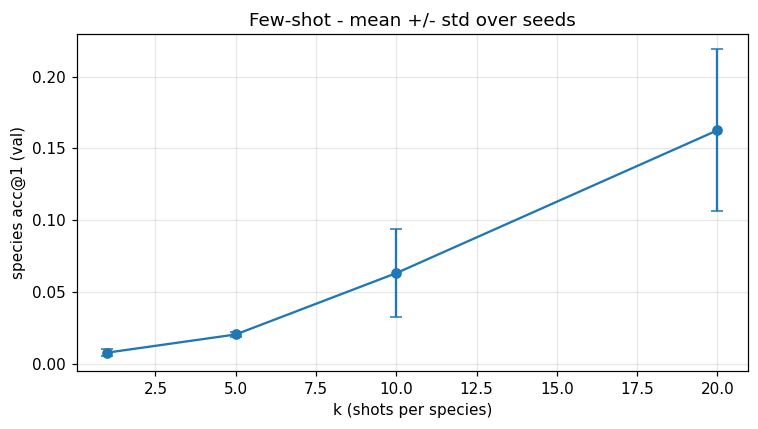

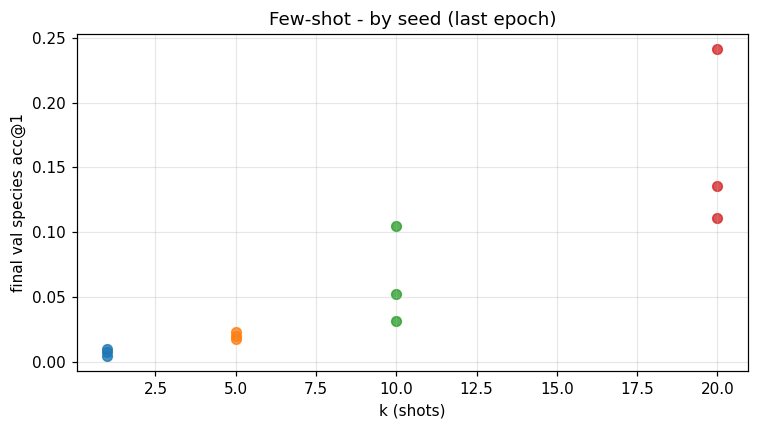

In [7]:
fs_sum = load_csv(OUT / 'fewshot_taxonomy' / 'summary.csv')
if fs_sum is None or fs_sum.empty:
    print('No fewshot summary.csv. Run notebook 04.')
else:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.errorbar(
        fs_sum['k'],
        fs_sum['species_acc_top1_mean'],
        yerr=fs_sum['species_acc_top1_std'],
        marker='o',
        capsize=4,
    )
    ax.set_xlabel('k (shots per species)')
    ax.set_ylabel('species acc@1 (val)')
    ax.set_title('Few-shot - mean +/- std over seeds')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    paths = sorted(OUT.glob('fewshot_taxonomy/k*_seed*/history.csv'))
    if paths:
        pts = []
        for p in paths:
            m = re.match(r'k(\d+)_seed(\d+)', p.parent.name)
            if not m:
                continue
            k, seed = int(m.group(1)), int(m.group(2))
            df = pd.read_csv(p)
            if df.empty or 'val_species_acc_top1' not in df.columns:
                continue
            last = df.iloc[-1]['val_species_acc_top1']
            pts.append((k, seed, last))
        if pts:
            fig, ax = plt.subplots(figsize=(7, 4))
            for k in sorted({t[0] for t in pts}):
                ys = [t[2] for t in pts if t[0] == k]
                ax.scatter([k] * len(ys), ys, alpha=0.8, s=40)
            ax.set_xlabel('k (shots)')
            ax.set_ylabel('final val species acc@1')
            ax.set_title('Few-shot - by seed (last epoch)')
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()


## 7. Checkpoint size and inference time (ENDG511 Lab 2 style)

**Val species acc@1** (from `val_metrics_last.json`), **raw vs zip-deflated size**, **forward ms/image** (dummy 224 batch). Skips missing checkpoints.


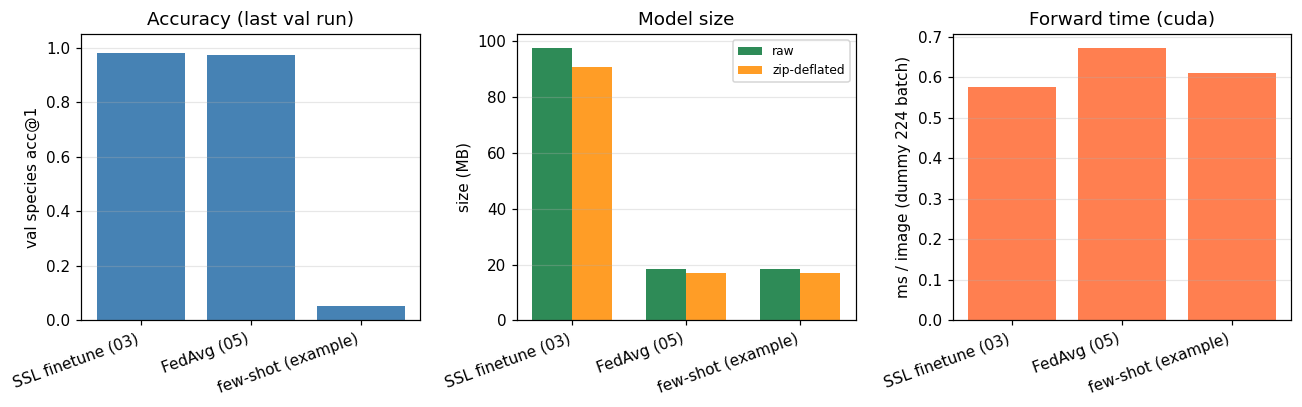

In [8]:
def _gzip_zip_size(path: Path) -> int:
    _, zpath = tempfile.mkstemp(suffix='.zip')
    try:
        with zipfile.ZipFile(zpath, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
            zf.write(path, arcname=path.name)
        return os.path.getsize(zpath)
    finally:
        try:
            os.remove(zpath)
        except OSError:
            pass


def _bench_forward(path: Path, device: torch.device, batch: int = 8, warmup: int = 5, iters: int = 40) -> float:
    ckpt = load_taxonomy_checkpoint_auto(path, map_location='cpu')
    model = load_taxonomy_for_inference(ckpt)
    comp = ckpt.get('compression') or {}
    use = torch.device('cpu') if comp.get('quantized') else device
    model.to(use).eval()
    x = torch.randn(batch, 3, 224, 224, device=use)
    with torch.inference_mode():
        for _ in range(warmup):
            model(x)
        t0 = time.perf_counter()
        for _ in range(iters):
            model(x)
        dt = time.perf_counter() - t0
    return dt / (iters * batch)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CKPT_SPECS = [
    ('SSL finetune (03)', OUT / 'taxonomy_ssl' / 'taxonomy_ssl_resnet50.pt', OUT / 'taxonomy_ssl' / 'val_metrics_last.json'),
    ('FedAvg (05)', OUT / 'federated_fedavg' / 'fedavg_global_model.pt', OUT / 'federated_fedavg' / 'val_metrics_last.json'),
]
few_models = sorted(OUT.glob('fewshot_taxonomy/k*_seed*/model.pt'))
if few_models:
    fm = few_models[0]
    CKPT_SPECS.append(('few-shot (example)', fm, fm.parent / 'val_metrics_last.json'))
comp_ssl = OUT / 'taxonomy_ssl' / 'taxonomy_ssl_resnet50_compressed.huff.pt'
if comp_ssl.is_file():
    CKPT_SPECS.append(('compressed SSL (08)', comp_ssl, OUT / 'taxonomy_ssl' / 'val_metrics_last.json'))

labels, accs, raw_sizes, zip_sizes, t_per_img = [], [], [], [], []
for label, pt, val_json in CKPT_SPECS:
    if not pt.is_file():
        continue
    vm = load_json(val_json) if val_json.is_file() else None
    acc = float(vm['species']['acc_top1']) if vm and 'species' in vm else float('nan')
    labels.append(label)
    accs.append(acc)
    raw_sizes.append(pt.stat().st_size)
    zip_sizes.append(_gzip_zip_size(pt))
    try:
        t_per_img.append(_bench_forward(pt, device))
    except Exception as e:
        print('Bench failed', label, e)
        t_per_img.append(float('nan'))

if not labels:
    print('No taxonomy checkpoints found under outputs/.')
else:
    x = np.arange(len(labels))
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
    axes[0].bar(x, accs, color='steelblue')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, rotation=20, ha='right')
    axes[0].set_ylabel('val species acc@1')
    axes[0].set_title('Accuracy (last val run)')
    axes[0].set_ylim(0, 1.05)
    axes[0].grid(True, axis='y', alpha=0.3)

    w = 0.35
    axes[1].bar(x - w / 2, np.array(raw_sizes) / 1e6, width=w, color='seagreen', label='raw')
    axes[1].bar(x + w / 2, np.array(zip_sizes) / 1e6, width=w, color='darkorange', alpha=0.85, label='zip-deflated')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=20, ha='right')
    axes[1].set_ylabel('size (MB)')
    axes[1].set_title('Model size')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, axis='y', alpha=0.3)

    axes[2].bar(x, np.array(t_per_img) * 1000, color='coral')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(labels, rotation=20, ha='right')
    axes[2].set_ylabel('ms / image (dummy 224 batch)')
    axes[2].set_title(f'Forward time ({device.type})')
    axes[2].grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


## 8. Reading the figures

- **SimCLR:** contrastive loss only; taxonomy quality comes from **03**.
- **Train vs val curves:** need fresh `history.csv` after `taxonomy_train` updates.
- **Species acc@1 vs macro-F1:** acc can be high with easy classes; macro-F1 stresses rare classes.
- **FedAvg:** x-axis is **communication rounds**, not epochs.
- **Few-shot:** high variance at small **k**.
- **Size/latency bars:** timing is **relative** (dummy input, same batch for all).

**Demo:** notebook `07` (Gradio, full-image taxonomy).
